<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [2]:
# Step 2: Examine the Structure of the Data

# 1. Dataset dimensions
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# 2. Column names
print("\nColumn names:")
print(df.columns.tolist())

# 3. Data types
print("\nData types:")
display(
    pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str)
    })
)

# 4. Summary information
print("\nDataset information:")
df.info()

Dataset shape: (65437, 114)
Number of rows: 65437
Number of columns: 114

Column names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpS

,Column,Data Type
ResponseId,ResponseId,int64
MainBranch,MainBranch,str
Age,Age,str
Employment,Employment,str
RemoteWork,RemoteWork,str
...,...,...
JobSatPoints_11,JobSatPoints_11,float64
SurveyLength,SurveyLength,str
SurveyEase,SurveyEase,str
ConvertedCompYearly,ConvertedCompYearly,float64



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB


### Analysis – Dataset Structure

The dataset contains **65,437 records and 114 variables**, providing a broad set of information collected from the survey respondents.

The data types are distributed as follows:

* **100 string (`str`) columns**, mainly representing categorical or text-based information such as employment status, remote work, technologies, and survey responses.
* **13 `float64` columns**, representing numerical variables that may also contain missing values.
* **1 `int64` column**, corresponding to `ResponseId`, which serves as the numerical identifier for each survey response.

The dataset uses approximately **56.9 MB of memory**, indicating that it is large enough to require structured data-quality checks before performing deeper analysis.

This initial inspection confirms that the dataset contains a combination of categorical and numerical variables. Since most columns are stored as strings, some variables that represent quantities or experience levels may require conversion before statistical analysis.

At this stage, **no missing values have been removed, no values have been imputed, and no data types have been modified**. The dataset remains in its original loaded state so that data quality can be evaluated in the next step.


### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [3]:
# Step 3: Identify and assess missing values

# Count missing values and percentages
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

# Keep only columns containing missing values
missing_summary = (
    missing_summary[missing_summary["Missing Values"] > 0]
    .sort_values("Missing Values", ascending=False)
)

print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])
print("Columns with missing values:", len(missing_summary))
print("Total missing cells:", df.isna().sum().sum())

display(missing_summary)

Total rows: 65437
Total columns: 114
Columns with missing values: 109
Total missing cells: 2890957


,Missing Values,Missing Percentage
AINextMuch less integrated,64289,98.25
AINextLess integrated,63082,96.40
AINextNo change,52939,80.90
AINextMuch more integrated,51999,79.46
EmbeddedAdmired,48704,74.43
...,...,...
YearsCode,5568,8.51
NEWSOSites,5151,7.87
LearnCode,4949,7.56
EdLevel,4653,7.11


In [4]:
# Additional missing-data assessment

# Completely empty rows
empty_rows = df.isna().all(axis=1).sum()

# Completely empty columns
empty_columns = df.isna().all(axis=0).sum()

print("Completely empty rows:", empty_rows)
print("Completely empty columns:", empty_columns)

# Top 15 columns with the most missing values
display(missing_summary.head(15))

Completely empty rows: 0
Completely empty columns: 0


,Missing Values,Missing Percentage
AINextMuch less integrated,64289,98.25
AINextLess integrated,63082,96.40
AINextNo change,52939,80.90
AINextMuch more integrated,51999,79.46
EmbeddedAdmired,48704,74.43
EmbeddedWantToWorkWith,47837,73.10
EmbeddedHaveWorkedWith,43223,66.05
ConvertedCompYearly,42002,64.19
AIToolNot interested in Using,41023,62.69
AINextMore integrated,41009,62.67


In [5]:
# Missing-data strategy:
# Keep the original dataframe unchanged.
# Missing values will be handled selectively
# within the variables required for each analysis.

df_clean = df.copy()

### Analysis – Missing Data

The missing-data assessment identified a substantial level of incompleteness across the survey dataset.

Out of **114 variables, 109 contain missing values**, representing a total of **2,890,957 missing cells**.

However, the dataset contains **0 completely empty rows and 0 completely empty columns**. This does **not** mean that every record is complete. Individual rows and columns may contain several `NaN` values, but none of them are entirely composed of missing values. In other words, every row and every column contains at least one valid observation.

Several variables show particularly high levels of missingness. For example, some AI-related variables exceed **90% missing values**, while `ConvertedCompYearly` is missing for approximately **64% of respondents**. These patterns suggest that some survey questions were optional, conditional, or not applicable to every participant.

Because of this structure, applying a global imputation method such as replacing missing values with a mean, median, or mode could introduce a large amount of artificial information. Likewise, removing every row containing at least one missing value could discard a substantial amount of otherwise valid data.

Therefore, the dataset will be preserved in its original form, and missing values will be handled **selectively according to the variables required for each analysis**. Records will only be excluded from a specific calculation when the necessary variables for that calculation are missing.

This strategy preserves valid survey responses while minimizing unnecessary data loss and reducing the risk of introducing bias through artificial imputation.


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [7]:
# Step 4: Analyze Key Columns

key_columns = ["Employment", "JobSat", "YearsCodePro"]

for column in key_columns:
    
    print(f"\n{'='*60}")
    print(f"Column: {column}")
    print(f"{'='*60}")

    total = len(df[column])
    missing = df[column].isna().sum()
    valid = df[column].notna().sum()

    print(f"Total records: {total}")
    print(f"Valid responses: {valid}")
    print(f"Missing values (NaN): {missing}")
    print(f"Missing percentage: {(missing / total) * 100:.2f}%")

    print("\nValue distribution:")
    
    display(
        df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="Count")
    )


Column: Employment
Total records: 65437
Valid responses: 65437
Missing values (NaN): 0
Missing percentage: 0.00%

Value distribution:


,Employment,Count
0,"Employed, full-time",39041
1,"Independent contractor, freelancer, or self-em...",4846
2,"Student, full-time",4709
3,"Employed, full-time;Independent contractor, fr...",3557
4,"Not employed, but looking for work",2341
...,...,...
105,"Not employed, but looking for work;Independent...",1
106,"Student, full-time;Retired",1
107,"Employed, full-time;Not employed, but looking ...",1
108,"Not employed, and not looking for work;Student...",1



Column: JobSat
Total records: 65437
Valid responses: 29126
Missing values (NaN): 36311
Missing percentage: 55.49%

Value distribution:


,JobSat,Count
0,NaN,36311
1,8.0,7509
2,7.0,6379
3,6.0,3751
4,9.0,3626
5,10.0,2251
6,5.0,1956
7,3.0,1165
8,4.0,1130
9,2.0,772



Column: YearsCodePro
Total records: 65437
Valid responses: 51610
Missing values (NaN): 13827
Missing percentage: 21.13%

Value distribution:


,YearsCodePro,Count
0,NaN,13827
1,2,4168
2,3,4093
3,5,3526
4,10,3251
5,4,3215
6,Less than 1 year,2856
7,6,2843
8,1,2639
9,8,2549


### Analysis – Key Columns

The analysis of `Employment`, `JobSat`, and `YearsCodePro` reveals important differences in both response distribution and data completeness.

For `Employment`, all **65,437 records contain a valid response**, with no missing values. The most common category is **Employed, full-time**, with 39,041 respondents. Other frequent categories include independent contractors or freelancers, full-time students, part-time employees, and respondents who are unemployed but looking for work. The column contains **110 distinct response combinations**, which indicates that respondents could report more than one employment situation and that each combination is counted as a separate category.

`JobSat` presents a very different level of completeness. Only **29,126 respondents provided a job satisfaction score**, while **36,311 values are missing**, representing **55.49% of the dataset**. Among the available responses, a score of **8** is the most frequent, followed by **7**, while scores between 7 and 9 appear prominently in the distribution. This suggests that respondents who answered the question generally reported moderate-to-high job satisfaction. However, because more than half of the observations are missing, conclusions about job satisfaction should be based only on the available responses and interpreted with caution.

For `YearsCodePro`, **51,610 valid responses** are available and **13,827 values are missing**, corresponding to **21.13%** of the records. Compared with `JobSat`, this variable has substantially better coverage and therefore provides a larger sample for analyzing professional coding experience.

Overall, the three variables have different levels of completeness. `Employment` has complete coverage, `YearsCodePro` contains a moderate amount of missing data, and `JobSat` has substantial missingness. These differences should be considered in subsequent analyses, particularly when comparing job satisfaction with professional experience, since only records containing valid values for the required variables should be included.


### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


Total records: 65437
Valid JobSat responses: 29126
Missing JobSat responses: 36311
Valid response rate: 44.51%


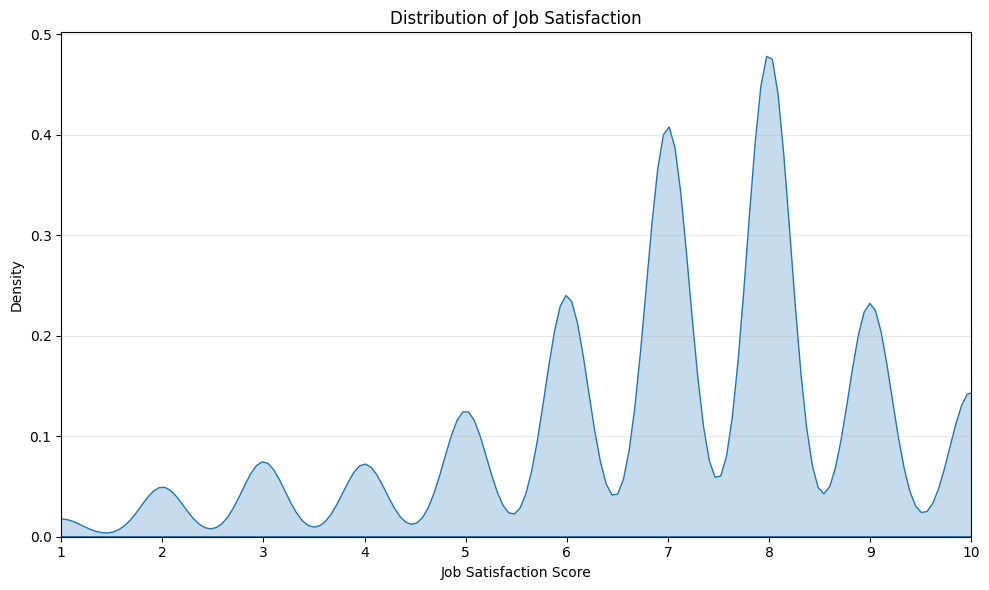

In [11]:
# Step 5: Visualize Job Satisfaction

# Keep only valid JobSat responses
job_sat = df["JobSat"].dropna()

print(f"Total records: {len(df)}")
print(f"Valid JobSat responses: {job_sat.count()}")
print(f"Missing JobSat responses: {df['JobSat'].isna().sum()}")
print(f"Valid response rate: {(job_sat.count() / len(df)) * 100:.2f}%")

# KDE plot
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=job_sat,
    fill=True,
    bw_adjust=0.8
)

plt.title("Distribution of Job Satisfaction")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Density")

plt.xticks(range(1, 11))
plt.xlim(1, 10)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Analysis – Job Satisfaction

The distribution of `JobSat` shows that job satisfaction among respondents who answered this question is concentrated mainly in the **upper part of the 1–10 scale**.

The highest concentration occurs around a satisfaction score of **8**, followed by **7**. Scores of **6 and 9** also represent noticeable portions of the distribution, while lower satisfaction levels between **1 and 4** appear considerably less frequently.

Overall, the pattern suggests that respondents who provided a job satisfaction score generally report **moderate to high levels of satisfaction**, with responses clustering primarily between **6 and 9**.

However, this result should be interpreted with caution because only **29,126 of the 65,437 respondents** provided a valid `JobSat` value. Approximately **55.49% of the observations are missing** for this variable. Therefore, the visualization represents the distribution of respondents who answered the job satisfaction question and should not automatically be generalized to the entire survey population.

No missing values were imputed for this analysis. Only valid `JobSat` responses were included in the visualization, preserving the integrity of the original survey responses.


### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


In [12]:
# Step 6: Programming Languages Analysis

# Check data availability
print("LanguageHaveWorkedWith:")
print("Valid responses:", df["LanguageHaveWorkedWith"].notna().sum())
print("Missing values:", df["LanguageHaveWorkedWith"].isna().sum())

print("\nLanguageWantToWorkWith:")
print("Valid responses:", df["LanguageWantToWorkWith"].notna().sum())
print("Missing values:", df["LanguageWantToWorkWith"].isna().sum())


# Split multiple languages and count each language separately
have_counts = (
    df["LanguageHaveWorkedWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

want_counts = (
    df["LanguageWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)


# Combine both distributions
language_comparison = pd.concat(
    [have_counts, want_counts],
    axis=1,
    keys=["Have Worked With", "Want To Work With"]
).fillna(0).astype(int)

# Total mentions used only to select the most relevant languages
language_comparison["Total"] = (
    language_comparison["Have Worked With"]
    + language_comparison["Want To Work With"]
)

# Top 15 languages
top_languages = (
    language_comparison
    .sort_values("Total", ascending=False)
    .head(15)
)

display(top_languages)

LanguageHaveWorkedWith:
Valid responses: 59745
Missing values: 5692

LanguageWantToWorkWith:
Valid responses: 55752
Missing values: 9685


,Have Worked With,Want To Work With,Total
JavaScript,37492,23774,61266
Python,30719,25047,55766
SQL,30682,22400,53082
HTML/CSS,31816,20721,52537
TypeScript,23150,20239,43389
Bash/Shell (all shells),20412,13744,34156
C#,16318,12921,29239
Java,18239,10668,28907
Rust,7559,17232,24791
C++,13827,10873,24700


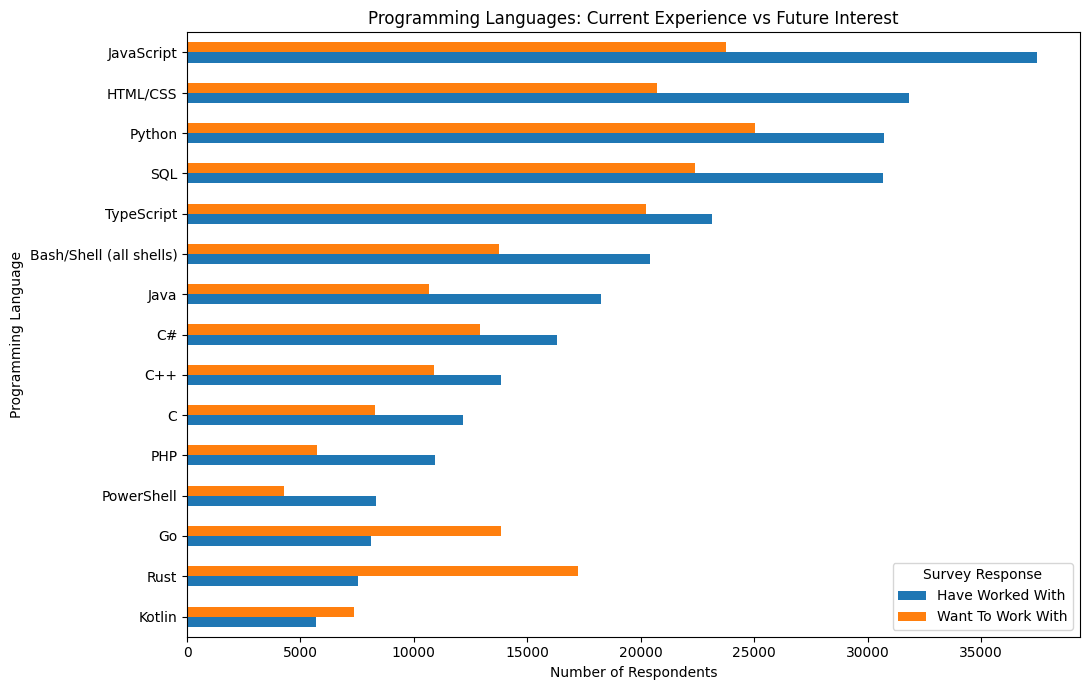

In [13]:
# Grouped bar chart

plot_data = (
    top_languages[
        ["Have Worked With", "Want To Work With"]
    ]
    .sort_values("Have Worked With")
)

plot_data.plot(
    kind="barh",
    figsize=(11, 7)
)

plt.title("Programming Languages: Current Experience vs Future Interest")
plt.xlabel("Number of Respondents")
plt.ylabel("Programming Language")
plt.legend(title="Survey Response")
plt.tight_layout()
plt.show()

### Analysis – Programming Languages

The comparison between `LanguageHaveWorkedWith` and `LanguageWantToWorkWith` highlights differences between developers' **current experience** and their **future technology interests**.

`JavaScript` is the most frequently used language among respondents, followed by `HTML/CSS`, `Python`, and `SQL`. These technologies show a strong established presence within the developer community.

`Python` also shows one of the highest levels of future interest, with the gap between current usage and desired future usage being relatively small compared with several other widely used technologies. This suggests that Python maintains both strong adoption and continued developer interest.

In contrast, languages such as `JavaScript`, `HTML/CSS`, `Java`, `C`, `PHP`, and `PowerShell` show noticeably higher current usage than future interest. This does not necessarily indicate that these technologies are declining, but it suggests that fewer respondents selected them as technologies they specifically want to work with in the future.

A different pattern can be observed for technologies such as `Rust`, `Go`, and `Kotlin`. Their future-interest counts are higher than their current usage counts, with `Rust` showing a particularly large difference. This may indicate growing developer interest in these technologies despite their smaller current user base.

Overall, the results suggest a technology landscape where established languages such as JavaScript, SQL, and Python remain highly relevant, while languages such as Rust and Go demonstrate notable potential for future adoption.

Missing responses were excluded only from the corresponding language analysis, and each semicolon-separated language selection was counted individually rather than treating multiple selections as a single category.


### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [14]:
# Check available geographic variables

geo_columns = [
    col for col in df.columns
    if any(term in col.lower() for term in ["region", "country", "location"])
]

print("Available geographic columns:")
print(geo_columns)

print("\nRemoteWork distribution:")
display(df["RemoteWork"].value_counts(dropna=False))

Available geographic columns:
['Country']

RemoteWork distribution:


RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
NaN                                     10631
Name: count, dtype: int64

In [15]:
print("RemoteWork missing values:", df["RemoteWork"].isna().sum())
print(
    "RemoteWork missing percentage:",
    round(df["RemoteWork"].isna().mean() * 100, 2),
    "%"
)

RemoteWork missing values: 10631
RemoteWork missing percentage: 16.25 %


In [16]:
# Step 7: Analyze Remote Work Trends by Country

remote_country = df[["Country", "RemoteWork"]].dropna()

# Select the 10 countries with the most valid RemoteWork responses
top_countries = (
    remote_country["Country"]
    .value_counts()
    .head(10)
    .index
)

remote_top = remote_country[
    remote_country["Country"].isin(top_countries)
]

# Percentage distribution of work arrangements within each country
remote_distribution = pd.crosstab(
    remote_top["Country"],
    remote_top["RemoteWork"],
    normalize="index"
) * 100

display(remote_distribution.round(2))

RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote
Country,,,
Brazil,25.58,15.71,58.72
Canada,35.75,12.86,51.39
France,57.61,19.76,22.63
Germany,56.70,15.15,28.15
India,38.13,34.68,27.19
Netherlands,66.32,19.20,14.48
Poland,35.07,10.26,54.67
Ukraine,21.06,4.75,74.19
United Kingdom of Great Britain and Northern Ireland,46.89,11.18,41.94


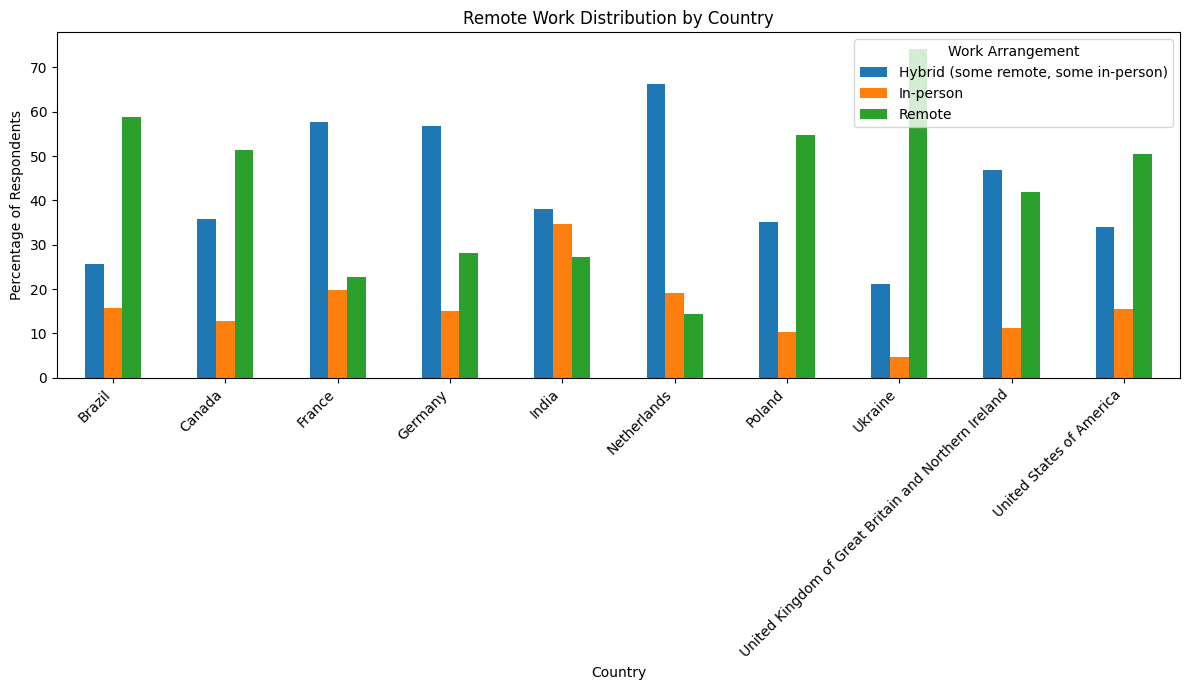

In [17]:
remote_distribution.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Remote Work Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Work Arrangement")
plt.tight_layout()
plt.show()

### Analysis – Remote Work Trends

The distribution of `RemoteWork` shows clear differences in work arrangements across the countries with the largest number of valid responses.

Remote work is particularly dominant in **Ukraine (74.19%)**, followed by **Brazil (58.72%)**, **Poland (54.67%)**, **Canada (51.39%)**, and the **United States (50.50%)**. These results indicate that fully remote work represents a significant share of respondents in these countries.

In contrast, **hybrid work** is the most common arrangement in several European countries. The **Netherlands (66.32%)**, **France (57.61%)**, and **Germany (56.70%)** show especially high proportions of hybrid workers. The **United Kingdom** also shows a strong hybrid pattern at **46.89%**, although remote work remains substantial at **41.94%**.

**India presents the most balanced distribution**, with 38.13% hybrid, 34.68% in-person, and 27.19% remote work. It also has the highest proportion of in-person work among the countries included in this comparison.

Because the dataset does not contain a specific `Region` variable, `Country` was used as the available geographic dimension. Percentages were calculated within each country rather than using absolute counts, allowing a more meaningful comparison between countries with different numbers of survey respondents.

Additionally, `RemoteWork` contains **10,631 missing values (16.25%)**. These missing observations were excluded only from this specific analysis and were not imputed, preserving the original survey responses.

Overall, the results suggest that work arrangements vary considerably by geographic location, with some countries showing a strong preference for fully remote work and others displaying a greater concentration of hybrid arrangements.


### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [18]:
# Step 8: Correlation between Job Satisfaction and Experience

# Convert YearsCodePro to a numeric representation
years_code_pro = (
    df["YearsCodePro"]
    .replace({
        "Less than 1 year": 0.5,
        "More than 50 years": 51
    })
)

years_code_pro = pd.to_numeric(
    years_code_pro,
    errors="coerce"
)

# Ensure JobSat is numeric
job_sat_numeric = pd.to_numeric(
    df["JobSat"],
    errors="coerce"
)

# Create a temporary dataset containing only valid pairs
correlation_df = pd.DataFrame({
    "YearsCodePro": years_code_pro,
    "JobSat": job_sat_numeric
}).dropna()

print("Total records:", len(df))
print("Valid paired observations:", len(correlation_df))
print(
    "Excluded observations:",
    len(df) - len(correlation_df)
)

# Calculate correlations
pearson_corr = correlation_df["YearsCodePro"].corr(
    correlation_df["JobSat"],
    method="pearson"
)

spearman_corr = correlation_df["YearsCodePro"].corr(
    correlation_df["JobSat"],
    method="spearman"
)

print(f"\nPearson correlation:  {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")

Total records: 65437
Valid paired observations: 28356
Excluded observations: 37081

Pearson correlation:  0.1042
Spearman correlation: 0.1192


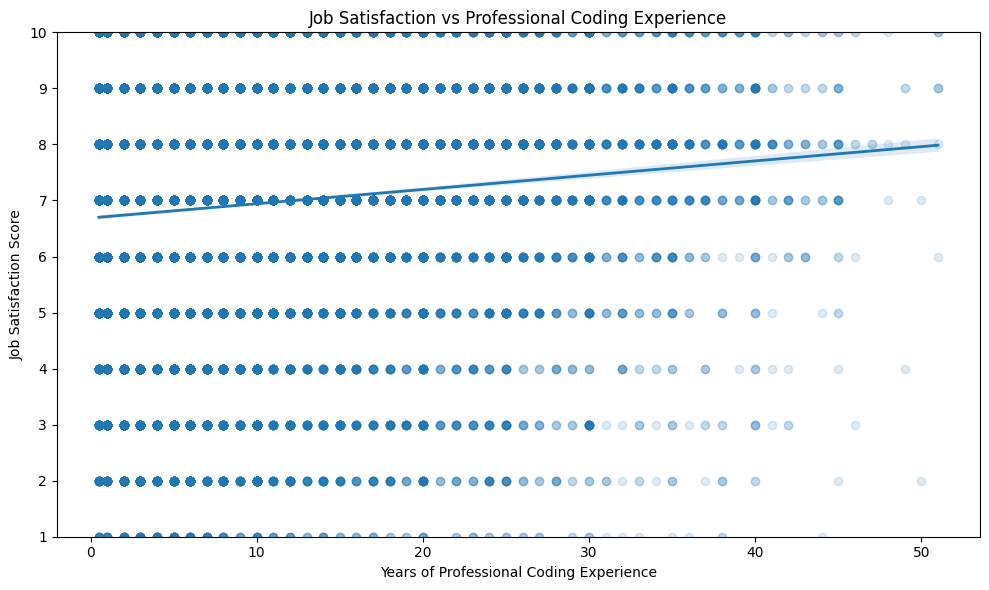

In [19]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=correlation_df,
    x="YearsCodePro",
    y="JobSat",
    scatter_kws={"alpha": 0.15},
    line_kws={"linewidth": 2}
)

plt.title("Job Satisfaction vs Professional Coding Experience")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Job Satisfaction Score")
plt.ylim(1, 10)
plt.tight_layout()
plt.show()

### Analysis – Correlation Between Job Satisfaction and Professional Experience

The relationship between `JobSat` and `YearsCodePro` was evaluated using both **Pearson** and **Spearman** correlation coefficients.

After excluding records where either variable was missing, **28,356 valid paired observations** remained from the original 65,437 records.

The results were:

* **Pearson correlation:** 0.1042
* **Spearman correlation:** 0.1192

Both coefficients indicate a **very weak positive relationship** between professional coding experience and job satisfaction. In practical terms, respondents with more years of professional experience tend to report slightly higher job satisfaction, but the relationship is too weak to consider professional experience a strong predictor of satisfaction.

#### Pearson vs. Spearman

**Pearson correlation** measures the strength of a **linear relationship** between two numerical variables. It is most appropriate when variables are continuous, the relationship is approximately linear, and extreme values do not strongly distort the analysis.

**Spearman correlation**, in contrast, is based on the **rank order of the observations** rather than their exact numerical distances. It measures whether two variables tend to increase or decrease together in a monotonic relationship and does not require the relationship to be strictly linear.

Spearman is generally preferable when:

* the variables are ordinal;
* the data are not normally distributed;
* the relationship may be monotonic but not linear;
* or the analysis should be less sensitive to extreme values.

For this analysis, **Spearman is the preferred coefficient for interpretation** because `JobSat` is measured on a discrete 1–10 satisfaction scale. Treating the difference between every satisfaction score as perfectly equivalent is a stronger assumption under Pearson.

The Spearman coefficient of **0.1192** therefore provides the primary measure of association and confirms that the relationship is positive but very weak.

#### Interpretation of the Visualization

The scatter plot includes a **linear regression line generated with `sns.regplot()`**. This regression line is conceptually more closely related to **Pearson correlation**, because it represents the best-fitting linear trend between professional experience and job satisfaction.

The slightly upward-sloping line is consistent with the positive Pearson coefficient of **0.1042**, but the wide dispersion of satisfaction scores around the line confirms that the linear relationship is weak.

Spearman was not directly represented by the regression line because Spearman is based on ranked values rather than fitting a linear equation to the original observations. It was calculated separately to provide a more appropriate statistical interpretation for the ordinal nature of job satisfaction.

Overall, both methods lead to the same conclusion: **professional coding experience has only a weak positive association with job satisfaction**, and other factors are likely to play a much larger role in determining how satisfied respondents are with their jobs.

No missing values were imputed. Only respondents with valid values for both `JobSat` and `YearsCodePro` were included in this correlation analysis.


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


In [22]:
# Step 9: Employment vs Education Level

employment_education = (
    df[["Employment", "EdLevel"]]
    .dropna()
    .copy()
)

print("Original records:", len(df))
print("Valid Employment + EdLevel records:", len(employment_education))
print(
    "Excluded due to missing values:",
    len(df) - len(employment_education)
)

# Separate multiple employment selections
employment_education["Employment"] = (
    employment_education["Employment"]
    .str.split(";")
)

# IMPORTANT: reset the index during explode
employment_education = employment_education.explode(
    "Employment",
    ignore_index=True
)

employment_education["Employment"] = (
    employment_education["Employment"]
    .str.strip()
)

# Cross-tabulation
employment_ed_crosstab = pd.crosstab(
    employment_education["Employment"],
    employment_education["EdLevel"]
)

print("\nCross-tabulation (counts):")
display(employment_ed_crosstab)

Original records: 65437
Valid Employment + EdLevel records: 60784
Excluded due to missing values: 4653

Cross-tabulation (counts):


EdLevel,"Associate degree (A.A., A.S., etc.)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Primary/elementary school,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",Some college/university study without earning a degree,Something else
Employment,,,,,,,,
"Employed, full-time",1260,19136,12489,201,2312,1860,4494,448
"Employed, part-time",137,1344,753,79,149,623,669,69
I prefer not to say,9,96,53,51,29,92,51,83
"Independent contractor, freelancer, or self-employed",323,3711,2679,159,485,902,1634,145
"Not employed, and not looking for work",22,226,110,155,23,338,174,45
"Not employed, but looking for work",127,1501,555,114,86,528,618,84
Retired,23,199,149,12,112,24,107,19
"Student, full-time",189,2034,584,583,87,2712,1484,166
"Student, part-time",98,817,345,90,46,427,522,66


In [23]:
# Percentage distribution of education within each employment category

employment_ed_pct = pd.crosstab(
    employment_education["Employment"],
    employment_education["EdLevel"],
    normalize="index"
) * 100

display(employment_ed_pct.round(2))

EdLevel,"Associate degree (A.A., A.S., etc.)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Primary/elementary school,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",Some college/university study without earning a degree,Something else
Employment,,,,,,,,
"Employed, full-time",2.99,45.35,29.59,0.48,5.48,4.41,10.65,1.06
"Employed, part-time",3.58,35.16,19.70,2.07,3.90,16.30,17.50,1.80
I prefer not to say,1.94,20.69,11.42,10.99,6.25,19.83,10.99,17.89
"Independent contractor, freelancer, or self-employed",3.22,36.97,26.69,1.58,4.83,8.99,16.28,1.44
"Not employed, and not looking for work",2.01,20.68,10.06,14.18,2.10,30.92,15.92,4.12
"Not employed, but looking for work",3.52,41.54,15.36,3.16,2.38,14.61,17.10,2.32
Retired,3.57,30.85,23.10,1.86,17.36,3.72,16.59,2.95
"Student, full-time",2.41,25.95,7.45,7.44,1.11,34.60,18.93,2.12
"Student, part-time",4.06,33.89,14.31,3.73,1.91,17.71,21.65,2.74


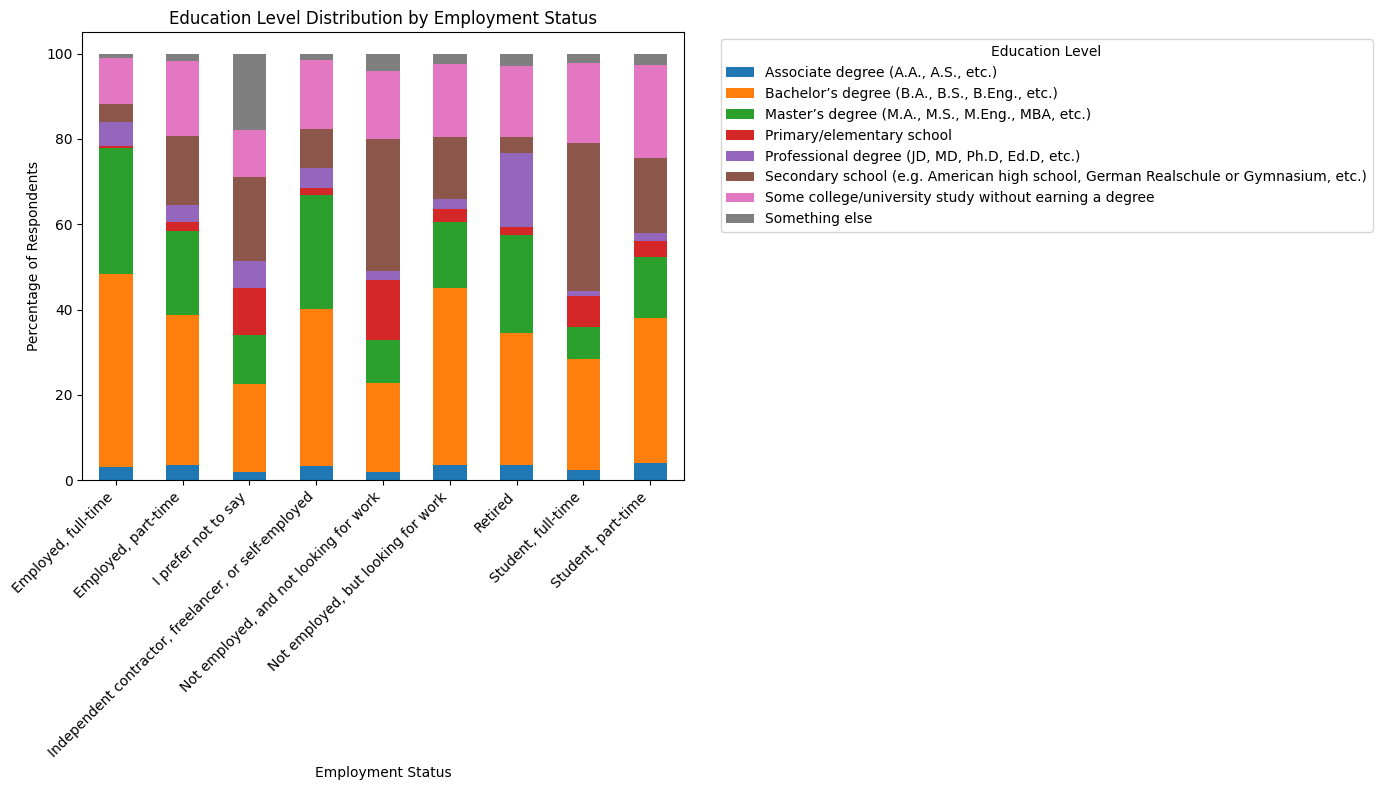

In [24]:
# Stacked bar chart

employment_ed_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8)
)

plt.title("Education Level Distribution by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Education Level",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Analysis – Employment Status vs. Education Level

The cross-tabulation and stacked bar chart show that the distribution of education levels varies across employment categories.

Among **full-time employees**, the largest proportion of respondents holds a **Bachelor’s degree**, followed by a substantial share with a **Master’s degree**. A similar pattern appears among **independent contractors, freelancers, and self-employed respondents**, suggesting that university-level education is common among professionally active respondents.

The student categories show a different profile. **Full-time and part-time students** contain larger proportions of respondents with **secondary education or some college/university study without a completed degree**, which is consistent with many respondents still being in the process of completing their education.

Respondents who are **not employed** show a more heterogeneous educational distribution, with greater representation across secondary education, university studies, and other education levels compared with the more concentrated pattern observed among full-time employees.

The chart uses **percentages within each employment category**, meaning that every bar totals approximately 100%. This normalization is important because employment groups contain different numbers of respondents; therefore, the visualization compares the **educational composition** of each group rather than their absolute population sizes.

Because `Employment` allows multiple selections, responses containing more than one employment status were separated before constructing the cross-tabulation. Consequently, a respondent may contribute to more than one employment category when multiple employment situations were reported.

For this analysis, **60,784 records contained valid values for both `Employment` and `EdLevel`**, while **4,653 records were excluded because one of these variables was missing**. Missing values were not imputed, and the original dataset was not modified.

Overall, the results indicate an observable association between employment status and educational background. However, this analysis is descriptive and does not by itself establish a statistically significant relationship or imply that education level causes a particular employment outcome.


### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [25]:
# Step 10: Export Cleaned Data

# Create a copy to preserve the original dataframe
df_clean = df.copy()

# Remove unnecessary leading/trailing spaces from text columns
text_columns = df_clean.select_dtypes(include=["object", "string"]).columns

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

# Add a numeric version of YearsCodePro
df_clean["YearsCodeProNumeric"] = (
    df_clean["YearsCodePro"]
    .replace({
        "Less than 1 year": 0.5,
        "More than 50 years": 51
    })
)

df_clean["YearsCodeProNumeric"] = pd.to_numeric(
    df_clean["YearsCodeProNumeric"],
    errors="coerce"
)

# Export to CSV
output_file = "survey_data_cleaned.csv"

df_clean.to_csv(
    output_file,
    index=False
)

print("File successfully exported:", output_file)
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

File successfully exported: survey_data_cleaned.csv
Original shape: (65437, 114)
Cleaned shape: (65437, 115)


In [26]:
# Validate exported file

df_check = pd.read_csv("survey_data_cleaned.csv")

print("Exported dataset shape:", df_check.shape)
print("File loaded successfully.")

display(df_check.head())

Exported dataset shape: (65437, 115)
File loaded successfully.


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,YearsCodeProNumeric
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,17.0
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN,27.0
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN,NaN


In [27]:
df_clean["YearsCodeProNumeric"]

0         NaN
1        17.0
2        27.0
3         NaN
4         NaN
         ... 
65432     3.0
65433     NaN
65434     5.0
65435     2.0
65436     NaN
Name: YearsCodeProNumeric, Length: 65437, dtype: float64

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.
